# Importing the Dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Data Collection & Analysis

In [2]:
# Loading data from CSV file to a Pandas DataFrame
insurance_dataset = pd.read_csv('insurance.csv')

In [3]:
insurance_dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
# Number of rows and column
insurance_dataset.shape

(1338, 7)

In [5]:
# Getting some inforamation about the dataset
insurance_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
# Checking for missing values
insurance_dataset.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

# Data Analysis

## - Statistical Measures of the dataset

In [7]:
insurance_dataset.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


<Axes: title={'center': 'Age Distribution'}, xlabel='age', ylabel='Density'>

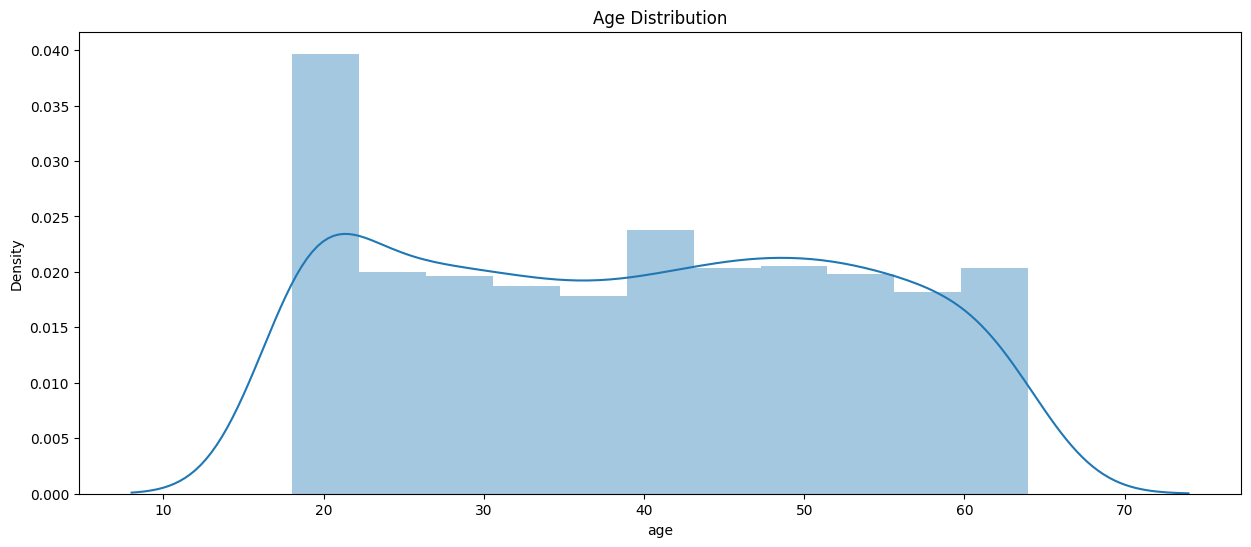

In [8]:
# Distribution of age value
plt.figure(figsize=(15,6))
plt.title("Age Distribution")
sns.distplot(insurance_dataset['age'])

In [9]:
# Create a new column that group the age
insurance_dataset['age_group'] = pd.cut(insurance_dataset['age'], bins = [0,18,25,35,45,60,100], labels = ["Child","Young Adult","Adult","Mid Age","Senior Adult","Elderly"])

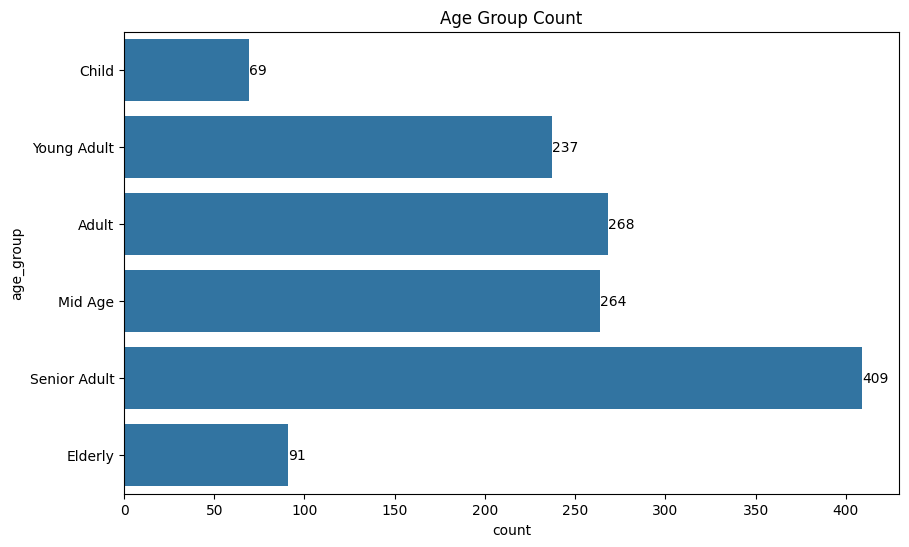

In [10]:
# Countplot for age_group
plt.figure(figsize=(10,6))
ax = sns.countplot(insurance_dataset['age_group'])
for container in ax.containers:
    ax.bar_label(container)

plt.title('Age Group Count')
plt.show()

In [11]:
# Create a new BMI group
insurance_dataset['bmi_group'] = pd.cut(insurance_dataset['bmi'], bins = [0, 18.5, 24.9, 29.9, 100], labels = ['Underweight', 'Normal', 'Overweight', 'Obese'])

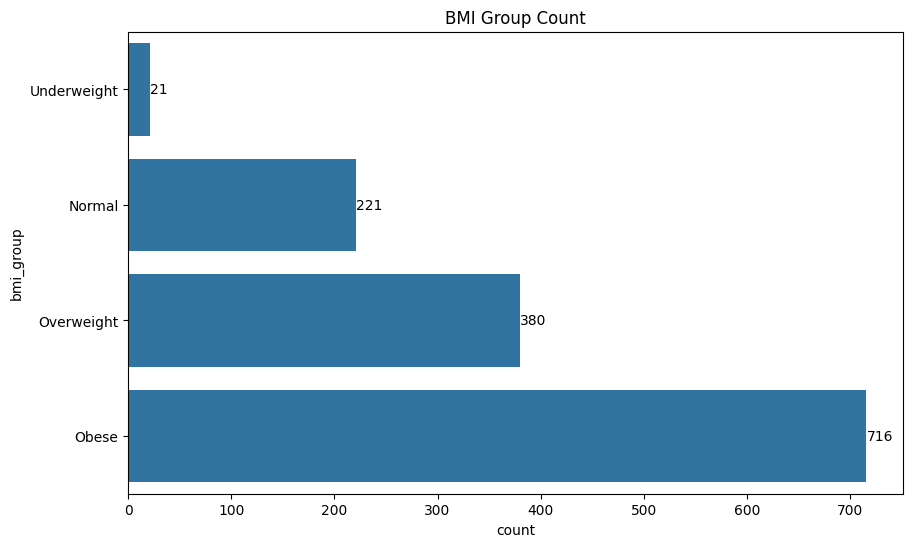

In [12]:
# Countplot for BMI Group 
plt.figure(figsize=(10,6))
ax = sns.countplot(insurance_dataset['bmi_group'])
for container in ax.containers:
    ax.bar_label(container)
plt.title('BMI Group Count')
plt.show()

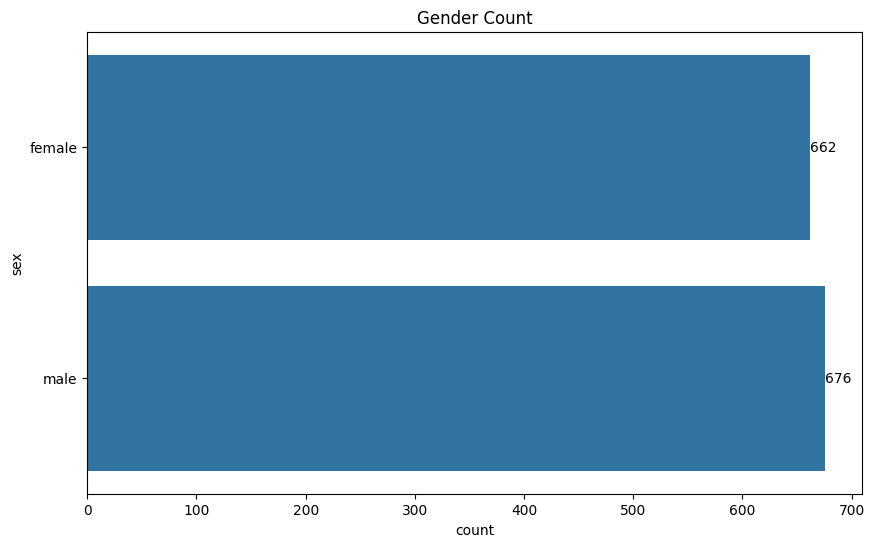

In [13]:
# Countplot for Gender 
plt.figure(figsize=(10,6))
ax = sns.countplot(insurance_dataset['sex'])
for container in ax.containers:
    ax.bar_label(container)
plt.title('Gender Count')
plt.show()

<Axes: title={'center': 'BMI Distribution'}, xlabel='bmi', ylabel='Density'>

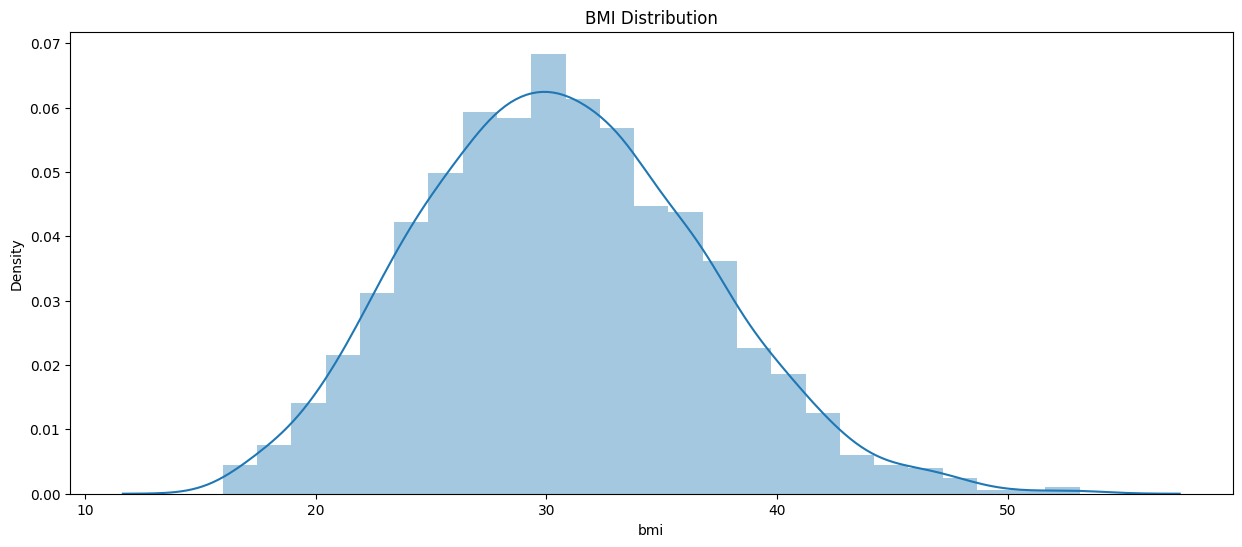

In [14]:
# Distribution of age value
plt.figure(figsize=(15,6))
plt.title("BMI Distribution")
sns.distplot(insurance_dataset['bmi'])

### Standard adult BMI ranges     
- Underweight: Below (18.5) 
- Healthy Weight: (18.5) to (24.9) 
- Overweight: (25.0) to (29.9) 
- Obesity: (30.0) or greater

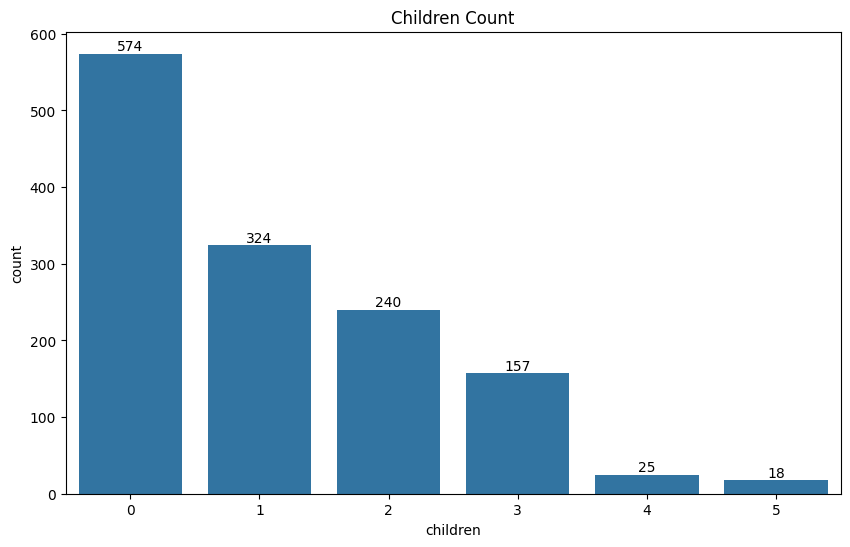

In [15]:
# Countplot of Children 
plt.figure(figsize=(10,6))
ax = sns.countplot(x=insurance_dataset['children'])
for container in ax.containers:
    ax.bar_label(container)
plt.title('Children Count')
plt.show()

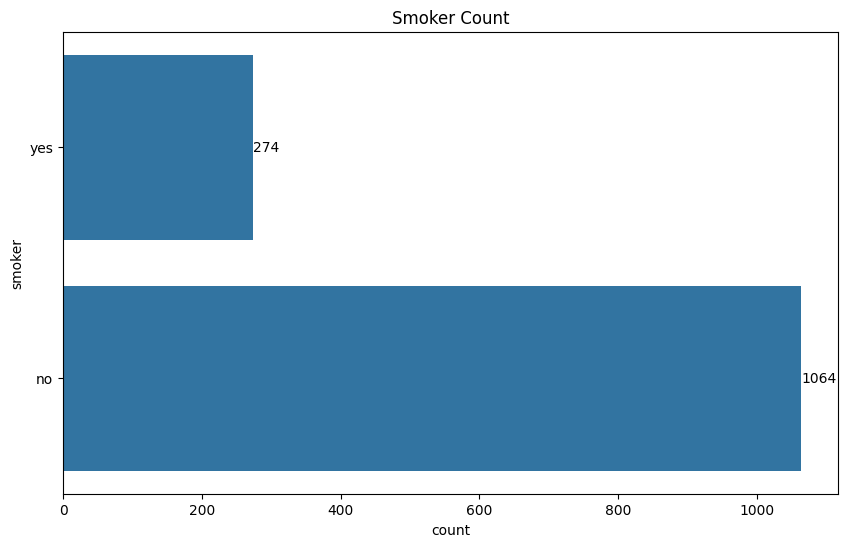

In [16]:
# Countplot of Smoker 
plt.figure(figsize=(10,6))
ax = sns.countplot(insurance_dataset['smoker'])
for container in ax.containers:
    ax.bar_label(container)
plt.title('Smoker Count')
plt.show()

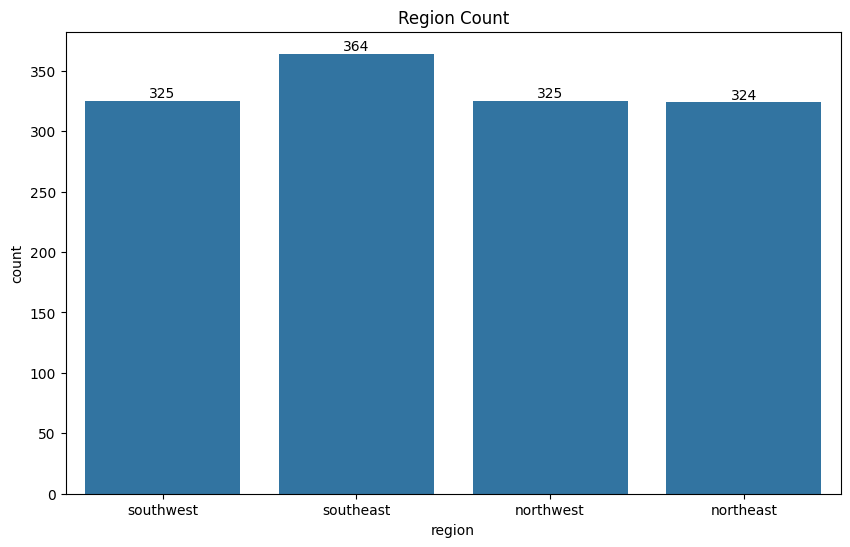

In [17]:
# Countplot for BMI Group 
plt.figure(figsize=(10,6))
ax = sns.countplot(x=insurance_dataset['region'])
for container in ax.containers:
    ax.bar_label(container)
plt.title('Region Count')
plt.show()

<Axes: title={'center': 'Charges Distribution'}, xlabel='charges', ylabel='Density'>

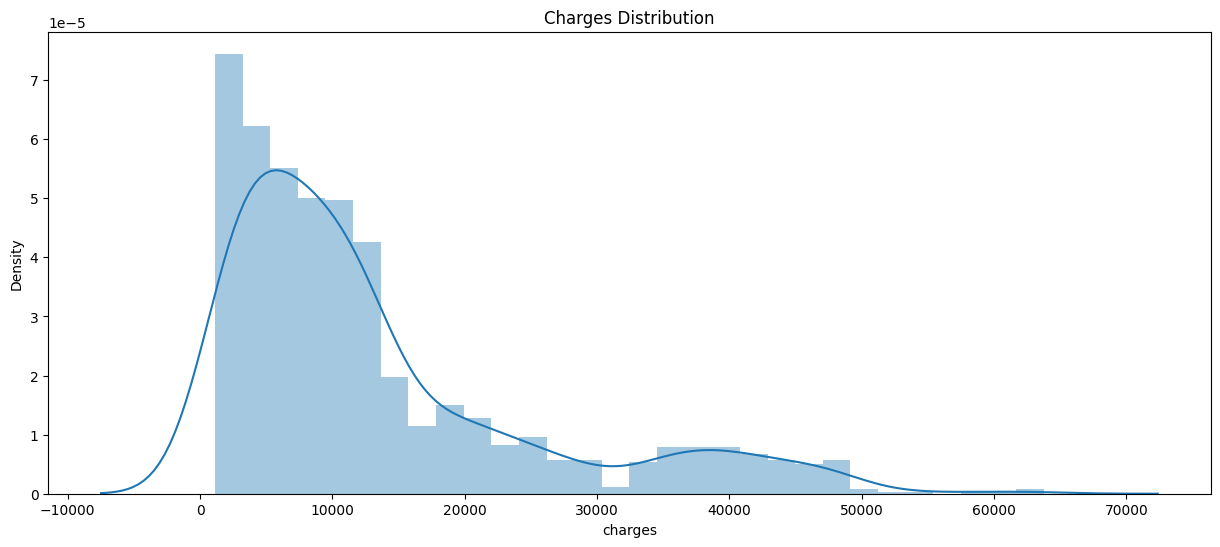

In [18]:
# Distribution of charges value
plt.figure(figsize=(15,6))
plt.title("Charges Distribution")
sns.distplot(insurance_dataset['charges'])

In [19]:
# Drop columns age_group and bmi_group
insurance_dataset = insurance_dataset.drop(columns=['age_group','bmi_group'])

In [20]:
insurance_dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Data Preprocessing

## - Encoding Categorical Features

In [21]:
insurance_dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

In [23]:
for col in ['sex','smoker','region']:
    insurance_dataset[col] = le.fit_transform(insurance_dataset[col])

In [24]:
insurance_dataset.sample(5)

,age,sex,bmi,children,smoker,region,charges
713,20,1,40.470,0,0,0,1984.45330
1057,45,0,31.790,0,0,2,17929.30337
623,18,1,33.535,0,1,0,34617.84065
996,39,0,34.100,3,0,3,7418.52200
62,64,1,24.700,1,0,1,30166.61817


## - Splitting the Featues & Target

In [25]:
X = insurance_dataset.drop(columns='charges',axis=1)
y = insurance_dataset['charges']

In [26]:
X

,age,sex,bmi,children,smoker,region
0,19,0,27.900,0,1,3
1,18,1,33.770,1,0,2
2,28,1,33.000,3,0,2
3,33,1,22.705,0,0,1
4,32,1,28.880,0,0,1
...,...,...,...,...,...,...
1333,50,1,30.970,3,0,1
1334,18,0,31.920,0,0,0
1335,18,0,36.850,0,0,2
1336,21,0,25.800,0,0,3


In [27]:
y

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

## - Split data into training data & testing data

In [38]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [39]:
print(X.shape,X_train.shape,X_test.shape)

(1338, 6) (1070, 6) (268, 6)


In [40]:
print(y.shape,y_train.shape,y_test.shape)

(1338,) (1070,) (268,)


# Model Training

In [43]:
# Loading LinearRegression model
import xgboost as xgb
model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)

In [44]:
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

# Model Evaluation

In [45]:
# Predication on training data
y_pred = model.predict(X_test)

In [46]:
from sklearn.metrics import mean_squared_error, r2_score
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.3f}')
print(f'R²: {r2:.3f}')

RMSE: 5362.200
R²: 0.809


In [47]:
insurance_dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


# Prediction

In [48]:
new_data = pd.DataFrame({
    'age': [18],
    'sex': [1],
    'bmi': [33.77],
    'children': [1],
    'smoker':[0],
    'region':[2],
})

predicted_charge = model.predict(new_data)
print("Predicted charge:", predicted_charge[0])

Predicted charge: 2174.6118


# Save Model

In [37]:
import pickle

# save model
with open("model.pkl", "wb") as file:
    pickle.dump(model, file)